In [33]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [34]:
import pandas as pd
import numpy as np

# For reproducibility
np.random.seed(42)

# 1️⃣ Generate timestamps (30 days, hourly data)
date_range = pd.date_range(start="2025-01-01", periods=24*30, freq="h")

# 2️⃣ Define buildings
buildings = ["Admin", "Library", "Lab"]

data = []

# 3️⃣ Generate data
for ts in date_range:
    hour = ts.hour
    day = ts.weekday()   # 0 = Monday, 6 = Sunday

    for building in buildings:
        base = 50

        # Building-specific patterns
        if building == "Admin":
            usage = base + (10 if 9 <= hour <= 17 else 3)

            # 🔻 Weekend dip (IMPORTANT INSIGHT)
            if day >= 5:
                usage -= 15

        elif building == "Library":
            usage = base + (15 if 10 <= hour <= 21 else 5)

        elif building == "Lab":
            usage = base + (20 if 8 <= hour <= 19 else 8)

        # 4️⃣ Add randomness (noise)
        usage += np.random.normal(0, 5)

        # Ensure no negative values
        usage = max(usage, 5)

        # Store row
        data.append([ts, building, hour, day, usage])

# 5️⃣ Create DataFrame
df = pd.DataFrame(data, columns=[
    "timestamp",
    "building",
    "hour",
    "day",
    "energy_consumption"
])

# 6️⃣ Save dataset
df.to_csv("synthetic_energy_dataset.csv", index=False)

print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
            timestamp building  hour  day  energy_consumption
0 2025-01-01 00:00:00    Admin     0    2           55.483571
1 2025-01-01 00:00:00  Library     0    2           54.308678
2 2025-01-01 00:00:00      Lab     0    2           61.238443
3 2025-01-01 01:00:00    Admin     1    2           60.615149
4 2025-01-01 01:00:00  Library     1    2           53.829233


In [35]:
#Prepare Features for Clustering
from sklearn.preprocessing import StandardScaler

features = df[['hour', 'day', 'energy_consumption']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [36]:
#Apply K-Means Clustering
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

print(df[['energy_consumption', 'cluster']].head())

   energy_consumption  cluster
0           55.483571        0
1           54.308678        0
2           61.238443        1
3           60.615149        1
4           53.829233        0


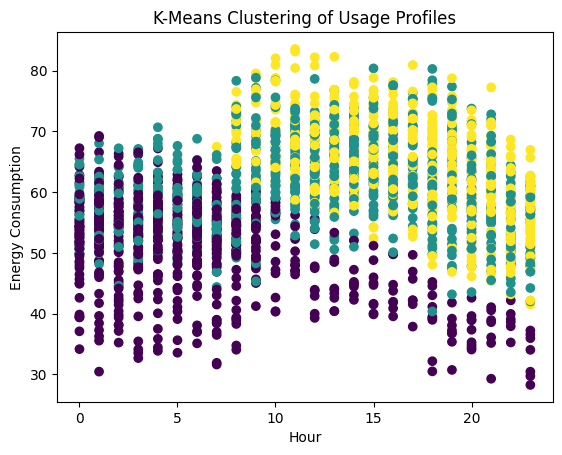

In [37]:
#Visualize Clusters
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['hour'], df['energy_consumption'], c=df['cluster'])
plt.xlabel("Hour")
plt.ylabel("Energy Consumption")
plt.title("K-Means Clustering of Usage Profiles")
plt.show()

In [38]:
#Regression Model per Cluster (Forecasting)
from sklearn.linear_model import LinearRegression

models = {}

for cluster in df['cluster'].unique():
    cluster_data = df[df['cluster'] == cluster]

    X = cluster_data[['hour', 'day']]
    y = cluster_data['energy_consumption']

    model = LinearRegression()
    model.fit(X, y)

    models[cluster] = model

print("Models trained for clusters:", models.keys())

Models trained for clusters: dict_keys([np.int32(0), np.int32(1), np.int32(2)])


In [39]:
# Example: Predict for hour=14 (2PM), day=2 (Wednesday)
future_input = pd.DataFrame({'hour': [14], 'day': [2]})

predictions = {}

for cluster, model in models.items():
    pred = model.predict(future_input)[0]
    predictions[cluster] = pred

print("Forecast per cluster:", predictions)

Forecast per cluster: {np.int32(0): np.float64(47.123431720199065), np.int32(1): np.float64(60.94110838461177), np.int32(2): np.float64(67.10692200642332)}


In [40]:
#Calculate Savings Potential
baseline = df['energy_consumption'].max()

cluster_avg = df.groupby('cluster')['energy_consumption'].mean()

savings = baseline - cluster_avg
savings_percent = (savings / baseline) * 100

print("Savings %:\n", savings_percent)

Savings %:
 cluster
0    39.318206
1    27.281331
2    23.024173
Name: energy_consumption, dtype: float64


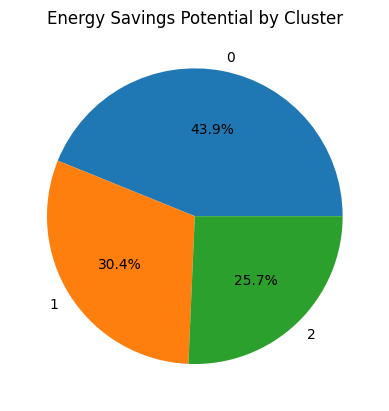

In [41]:
#Pie Chart (Dashboard Visualization)
plt.figure()
plt.pie(savings_percent, labels=savings_percent.index, autopct='%1.1f%%')
plt.title("Energy Savings Potential by Cluster")
plt.show()

In [42]:
#Insight: Admin Building Weekend Dip
admin = df[df['building'] == 'Admin']

weekend = admin[admin['day'] >= 5]
weekday = admin[admin['day'] < 5]

print("Admin Weekday Avg:", weekday['energy_consumption'].mean())
print("Admin Weekend Avg:", weekend['energy_consumption'].mean())

Admin Weekday Avg: 56.02433473367759
Admin Weekend Avg: 41.225809892202165
